Library

In [1]:
import os
import pandas as pd
import pdfplumber
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Load Text Data

In [2]:
from pathlib import Path

try:
    from pypdf import PdfReader
except Exception:
    PdfReader = None

personal_path = r"C:\Users\nhipk\OneDrive\0. Uni2024\Sem4\ML for Economists\FinalProject" #Edit your personal path here
folder_path = os.path.join(personal_path, "TermpaperFilesILIAS", "C_BundesbankMonthlyReports")
pdf_files = list(sorted(Path(folder_path).glob("*.pdf")))


# Process Data

## Skip unnecessary pages, tables, charts, figures

In [6]:
def load_pdfs_from_folder(folder_path):
    """
    Read all PDF files from a specified folder, skip the first 4 and last 4 pages,
    and extract prose text while completely filtering out tables, charts, and figures.
    """
    data = []

    # Check if the target folder exists
    if not os.path.exists(folder_path):
        print(f"Error: The directory '{folder_path}' does not exist.")
        return None

    # Iterate through all items within the folder
    for filename in os.listdir(folder_path):
        # Process only files with a .pdf extension (case-insensitive)
        if filename.lower().endswith(".pdf"):
            file_path = os.path.join(folder_path, filename)
            print(f"Processing: {filename}...")

            try:
                # Open PDF with pdfplumber to control spatial elements (tables)
                with pdfplumber.open(file_path) as pdf:
                    total_pages = len(pdf.pages)
                    
                    # Safe check: Only process if the file has more than 8 pages
                    if total_pages > 8:
                        full_text = ""
                        
                        # Slice the pages to skip the first 4 and last 4 pages
                        target_pages = pdf.pages[4:-4]
                        
                        # Loop through the sliced pages to extract text content
                        for page in target_pages:
                            tables = page.find_tables()
                            table_bboxes = [table.bbox for table in tables]
                            
                            # Helper function to check if a character object falls inside any table bbox
                            def not_within_table(obj):
                                x0, y0, x1, y1 = obj["x0"], obj["top"], obj["x1"], obj["bottom"]
                                for t_x0, t_y0, t_x1, t_y1 in table_bboxes:
                                    if (x0 >= t_x0 and x1 <= t_x1 and y0 >= t_y0 and y1 <= t_y1):
                                        return False  # Exclude character if it overlaps with a table
                                return True       # Keep character if it is outside
                            
                            # 2. Extract text excluding the filtered character coordinates
                            clean_page = page.filter(not_within_table)
                            page_text = clean_page.extract_text()
                            
                            if page_text:
                                # 3. Filter out lines starting with common figure, chart, or table labels
                                lines = page_text.split('\n')
                                clean_lines = []
                                for line in lines:
                                    stripped_line = line.strip().lower()
                                    # Skip figure/table captions or titles
                                    if stripped_line.startswith(('figure', 'chart', 'table', 'fig.')):
                                        continue
                                    clean_lines.append(line)
                                
                                full_text += "\n".join(clean_lines) + "\n"

                        # Append the filename and extracted text metadata to the list
                        data.append({"file_name": filename, "text": full_text.strip()})
                    else:
                        print(f"Skipped '{filename}': File only has {total_pages} pages (too short to drop 4 start/end pages).")

            except Exception as e:
                print(f"Error reading file {filename}: {e}")

    df = pd.DataFrame(data)
    return df

# Extraction process
df_sentiment = load_pdfs_from_folder(folder_path)


if df_sentiment is not None and not df_sentiment.empty:
    print(f"\nSuccessfully loaded {len(df_sentiment)} files!")
    display(df_sentiment)
else:
    print("\nNo PDF files found or the folder is empty.")

Processing: 2009-12-monatsbericht-data.pdf...
Processing: 2010-12-monatsbericht-data.pdf...
Processing: 2011-12-monatsbericht-data.pdf...
Processing: 2012-12-monatsbericht-data.pdf...
Processing: 2013-12-monatsbericht-data.pdf...
Processing: 2014-12-monatsbericht-data.pdf...
Processing: 2015-12-monatsbericht-data.pdf...
Processing: 2016-12-monatsbericht-data.pdf...
Processing: 2017-12-monatsbericht-data.pdf...
Processing: 2018-12-monatsbericht-data.pdf...
Processing: 2019-12-monatsbericht-data.pdf...
Processing: 2020-12-monatsbericht-data.pdf...
Processing: 2021-12-monatsbericht-data.pdf...
Processing: 2022-12-monatsbericht-data.pdf...
Processing: 2023-12-monatsbericht-data.pdf...

Successfully loaded 15 files!


,file_name,text
0,2009-12-monatsbericht-data.pdf,DEUTSCHE\nBUNDESBANK\nMonthlyReport\nDecember2...
1,2010-12-monatsbericht-data.pdf,DEUTSCHE\nBUNDESBANK\nMonthlyReport\nDecember2...
2,2011-12-monatsbericht-data.pdf,DEUTSCHE\nBUNDESBANK\nMonthly Report\nDecember...
3,2012-12-monatsbericht-data.pdf,Deutsche Bundesbank\nMonthly Report\nDecember ...
4,2013-12-monatsbericht-data.pdf,Deutsche Bundesbank\nMonthly Report\nDecember ...
5,2014-12-monatsbericht-data.pdf,Deutsche Bundesbank\nMonthly Report\nDecember ...
6,2015-12-monatsbericht-data.pdf,Deutsche Bundesbank\nMonthly Report\nDecember ...
7,2016-12-monatsbericht-data.pdf,Deutsche Bundesbank\nMonthly Report\nDecember ...
8,2017-12-monatsbericht-data.pdf,Deutsche Bundesbank\nMonthly Report\nDecember ...
9,2018-12-monatsbericht-data.pdf,Deutsche Bundesbank\nMonthly Report\nDecember ...


In [7]:
# Add date column as key
df_sentiment["report_date"] = (
    df_sentiment["file_name"].str[:7]
    )
df_sentiment["word_count"] = df_sentiment["text"].str.split().str.len()

display(df_sentiment)

,file_name,text,report_date,word_count
0,2009-12-monatsbericht-data.pdf,DEUTSCHE\nBUNDESBANK\nMonthlyReport\nDecember2...,2009-12,80457
1,2010-12-monatsbericht-data.pdf,DEUTSCHE\nBUNDESBANK\nMonthlyReport\nDecember2...,2010-12,82099
2,2011-12-monatsbericht-data.pdf,DEUTSCHE\nBUNDESBANK\nMonthly Report\nDecember...,2011-12,98072
3,2012-12-monatsbericht-data.pdf,Deutsche Bundesbank\nMonthly Report\nDecember ...,2012-12,89343
4,2013-12-monatsbericht-data.pdf,Deutsche Bundesbank\nMonthly Report\nDecember ...,2013-12,94106
5,2014-12-monatsbericht-data.pdf,Deutsche Bundesbank\nMonthly Report\nDecember ...,2014-12,87278
6,2015-12-monatsbericht-data.pdf,Deutsche Bundesbank\nMonthly Report\nDecember ...,2015-12,92328
7,2016-12-monatsbericht-data.pdf,Deutsche Bundesbank\nMonthly Report\nDecember ...,2016-12,94049
8,2017-12-monatsbericht-data.pdf,Deutsche Bundesbank\nMonthly Report\nDecember ...,2017-12,99983
9,2018-12-monatsbericht-data.pdf,Deutsche Bundesbank\nMonthly Report\nDecember ...,2018-12,93196


## Text Cleaning

In [8]:
# Clean white spaces, convert to lowercase and remove punctuation
punctuation_pattern = f"[{''.join([f'\\{c}' for c in string.punctuation])}]"
df_sentiment['cleaned_text'] = (
    df_sentiment['text']
    .str.replace(r'\s+', ' ', regex=True)
    .str.lower()
    .str.replace(punctuation_pattern, '', regex=True)
)

# Drop file_name and full text columns to keep the DataFrame clean for further analysis
df_sentiment = df_sentiment.drop(columns=["file_name", "text"])

## Tokenize Text

In [9]:
# Tokenize cleaned text
df_sentiment['tokens'] = df_sentiment['cleaned_text'].apply(word_tokenize)

# Token counts
df_sentiment["token_count"] = df_sentiment["tokens"].apply(len)
display(df_sentiment)

,report_date,word_count,cleaned_text,tokens,token_count
0,2009-12,80457,deutsche bundesbank monthlyreport december2009...,"[deutsche, bundesbank, monthlyreport, december...",76222
1,2010-12,82099,deutsche bundesbank monthlyreport december2010...,"[deutsche, bundesbank, monthlyreport, december...",77799
2,2011-12,98072,deutsche bundesbank monthly report december 20...,"[deutsche, bundesbank, monthly, report, decemb...",93440
3,2012-12,89343,deutsche bundesbank monthly report december 20...,"[deutsche, bundesbank, monthly, report, decemb...",84473
4,2013-12,94106,deutsche bundesbank monthly report december 20...,"[deutsche, bundesbank, monthly, report, decemb...",89778
5,2014-12,87278,deutsche bundesbank monthly report december 20...,"[deutsche, bundesbank, monthly, report, decemb...",82345
6,2015-12,92328,deutsche bundesbank monthly report december 20...,"[deutsche, bundesbank, monthly, report, decemb...",87202
7,2016-12,94049,deutsche bundesbank monthly report december 20...,"[deutsche, bundesbank, monthly, report, decemb...",88525
8,2017-12,99983,deutsche bundesbank monthly report december 20...,"[deutsche, bundesbank, monthly, report, decemb...",94326
9,2018-12,93196,deutsche bundesbank monthly report december 20...,"[deutsche, bundesbank, monthly, report, decemb...",87664


## Part-of-Speech (POS) Tagging and Filtering

In [10]:
nltk.download('averaged_perceptron_tagger_eng')

def pos_tag_and_filter(token_list):
    """
    Perform POS Tagging on a list of tokens and filter to keep only 
    specific parts of speech (Nouns, Verbs, Adjectives, Adverbs).
    """
    if not isinstance(token_list, list) or len(token_list) == 0:
        return []
    
    # 1. Apply POS Tagging to the list of tokens
    # Output is a list of tuples: [('token', 'TAG'), ...]
    tagged_tokens = nltk.pos_tag(token_list)
    
    # 2. Define the target POS tags we want to keep
    # N: Nouns (NN, NNS, NNP, NNPS)
    # V: Verbs (VB, VBD, VBG, VBN, VBP, VBZ)
    # J: Adjectives (JJ, JJR, JJS)
    # R: Adverbs (RB, RBR, RBS)
    target_prefixes = ('N', 'V', 'J', 'R')
    
    # 3. Filter tokens based on their POS tags
    filtered_tokens = [
        token for token, tag in tagged_tokens
        if tag.startswith(target_prefixes)
    ]
    
    return filtered_tokens

# Compute POS-tagged and filtered tokens, storing
df_sentiment['tokens'] = df_sentiment['tokens'].apply(pos_tag_and_filter)
df_sentiment["token_count"] = df_sentiment["tokens"].apply(len)

# Reconstruct the cleaned text from the filtered tokens
df_sentiment['cleaned_text'] = df_sentiment['tokens'].apply(lambda x: " ".join(x))


df_sentiment["word_count"] = df_sentiment["cleaned_text"].str.split().str.len()

display(df_sentiment)

[nltk_data] Error loading averaged_perceptron_tagger_eng: <urlopen
[nltk_data]     error [SSL: CERTIFICATE_VERIFY_FAILED] certificate
[nltk_data]     verify failed: unable to get local issuer certificate
[nltk_data]     (_ssl.c:1082)>


,report_date,word_count,cleaned_text,tokens,token_count
0,2009-12,28213,deutsche bundesbank monthlyreport december2009...,"[deutsche, bundesbank, monthlyreport, december...",28213
1,2010-12,28901,deutsche bundesbank monthlyreport december2010...,"[deutsche, bundesbank, monthlyreport, december...",28901
2,2011-12,34528,deutsche bundesbank monthly report december co...,"[deutsche, bundesbank, monthly, report, decemb...",34528
3,2012-12,30046,deutsche bundesbank monthly report december co...,"[deutsche, bundesbank, monthly, report, decemb...",30046
4,2013-12,35232,deutsche bundesbank monthly report december co...,"[deutsche, bundesbank, monthly, report, decemb...",35232
5,2014-12,28647,deutsche bundesbank monthly report december co...,"[deutsche, bundesbank, monthly, report, decemb...",28647
6,2015-12,31738,deutsche bundesbank monthly report december co...,"[deutsche, bundesbank, monthly, report, decemb...",31738
7,2016-12,32789,deutsche bundesbank monthly report december co...,"[deutsche, bundesbank, monthly, report, decemb...",32789
8,2017-12,36448,deutsche bundesbank monthly report december co...,"[deutsche, bundesbank, monthly, report, decemb...",36448
9,2018-12,32100,deutsche bundesbank monthly report december co...,"[deutsche, bundesbank, monthly, report, decemb...",32100


## Remove Stop Words and Custom Words

In [11]:
# Stop words and Custom Words
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

# Load standard English stop words
stop_words = set(stopwords.words("english"))
print(stop_words)


{'down', 'won', 'wouldn', 'both', 'until', "mustn't", 'those', "it's", "couldn't", 'his', 'll', 'needn', 'but', 'how', 'further', 'that', 'what', 'the', 'aren', 'after', "they've", "wasn't", 'which', 'who', 's', "aren't", 'a', 'you', "shouldn't", "wouldn't", 'm', 'during', 'on', 'all', 'some', "they're", 'should', 'was', 'own', 'does', "shan't", 'have', 'your', 'from', 'same', "you're", "it'll", 'our', 'as', 'themselves', 'were', "hadn't", 'doing', 'being', 'had', 'ma', 'through', 'before', 't', 'do', 'having', 'isn', 're', 'at', 'here', 'it', 'no', 'its', 'am', 'just', "mightn't", "we'll", 'him', 'o', 'her', "they'll", 'myself', 'hers', 'did', 'weren', "we've", "you'd", 'yourselves', 'been', 'only', 'doesn', "i'll", "i'd", 'under', "she'll", "he's", 'more', "we're", 'don', "she'd", 'shouldn', 'himself', 'haven', 'mightn', 'ours', 'nor', 'and', 'where', "i've", 'any', 'above', 'against', "weren't", 'we', 'shan', 'into', "isn't", "he'd", 'other', "i'm", 'once', 'again', 'because', 'is',

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nhipk\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nhipk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nhipk\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nhipk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [12]:
# A list of custom words to be removed
custom_stop_words = {"report", "monthly",  "deutsche", "german", "germany", "country", "countries", "european", "euro", "zone", "europe", "ecb", 
                     "bundesbank", "central", "bank", "bundesbankbericht", "bundesbankmonatsbericht", "bundesbankmonatsberichte", "bundesbankmonatsberichten", "bundesbankmonatsberichts", "bundesbankmonatsberichten", "bundesbankmonatsberichts", "bundesbankmonatsberichten", "bundesbankmonatsberichts", "bundesbankmonatsberichten", "bundesbankmonatsberichts", "bundesbankmonatsberichten", "monatsbericht", "bericht",
                     "crypto", "financial", "coin","total","asset","market","monetary", "policy",   
                     "january","february","march","april","may","june","july","august","september","october","november","december","year",
                     "data", "page", "figure", "chart", "appendix", "source", "statist","commentaries"
                    }
all_stop_words = custom_stop_words.union(stop_words)

# Remove stop words
df_sentiment['tokens'] = df_sentiment['tokens'].apply(lambda x: [word for word in x if word not in all_stop_words])

# Reconstruct the cleaned text from the filtered tokens
df_sentiment['cleaned_text'] = df_sentiment['tokens'].apply(lambda x: " ".join(x))

df_sentiment["token_count"] = df_sentiment["tokens"].str.len()

display(df_sentiment)

,report_date,word_count,cleaned_text,tokens,token_count
0,2009-12,28213,monthlyreport december2009 economicconditions ...,"[monthlyreport, december2009, economicconditio...",24853
1,2010-12,28901,monthlyreport december2010 economicconditions ...,"[monthlyreport, december2010, economicconditio...",25392
2,2011-12,34528,economic conditions underlying trends accordin...,"[economic, conditions, underlying, trends, acc...",29917
3,2012-12,30046,economic conditions considerable decline capit...,"[economic, conditions, considerable, decline, ...",26017
4,2013-12,35232,economic conditions seasonally adjusted level ...,"[economic, conditions, seasonally, adjusted, l...",30182
5,2014-12,28647,economic conditions bridge day suggested somew...,"[economic, conditions, bridge, day, suggested,...",24971
6,2015-12,31738,economic conditions area moved sideways leavin...,"[economic, conditions, area, moved, sideways, ...",27690
7,2016-12,32789,economic conditions leaving aside growth amoun...,"[economic, conditions, leaving, aside, growth,...",28346
8,2017-12,36448,economic conditions many production sites fed ...,"[economic, conditions, many, production, sites...",31370
9,2018-12,32100,economic conditions industry underlying trends...,"[economic, conditions, industry, underlying, t...",27609


## Remove short tokens, numbers, and tokens with underscores or special characters

In [13]:
def apply_regex_vocabulary_filter(token_list):
    """
    Filter a list of tokens using strict regex and string rules:
    - Removes tokens shorter than 3 characters (e.g., 'aa', 'ab').
    - Removes tokens containing any numbers/digits (e.g., 'a1', 'a15').
    - Removes tokens containing underscores or special metadata symbols (e.g., '_page_').
    """
    if not isinstance(token_list, list):
        return []
        
    cleaned_tokens = []
    for token in token_list:
        token = str(token).strip() # Ensure the token is a valid string and strip any spaces
        
        if len(token) < 3: # Check if token length is less than 3
            continue
            
        if any(char.isdigit() for char in token): # Check if token contains any numerical digits
            continue
            
        if not re.match(r'^[a-zA-Z]+$', token): # Check if token contains underscores or non-alphabetic characters

            continue
            
        # If the token passes all the criteria above, keep it
        cleaned_tokens.append(token)
        
    return cleaned_tokens

# Filter the original tokens column using the pattern-based rules
df_sentiment['tokens'] = df_sentiment['tokens'].apply(apply_regex_vocabulary_filter)

# Reconstruct the cleaned text from the filtered tokens
df_sentiment['cleaned_text'] = df_sentiment['tokens'].apply(lambda x: " ".join(x))

df_sentiment["word_count"] = df_sentiment["cleaned_text"].str.split().str.len()
df_sentiment["token_count"] = df_sentiment["tokens"].str.len()

display(df_sentiment)


,report_date,word_count,cleaned_text,tokens,token_count
0,2009-12,15580,monthlyreport economicconditions underlyingtre...,"[monthlyreport, economicconditions, underlying...",15580
1,2010-12,15883,monthlyreport economicconditions underlyingtre...,"[monthlyreport, economicconditions, underlying...",15883
2,2011-12,21007,economic conditions underlying trends accordin...,"[economic, conditions, underlying, trends, acc...",21007
3,2012-12,17169,economic conditions considerable decline capit...,"[economic, conditions, considerable, decline, ...",17169
4,2013-12,20701,economic conditions seasonally adjusted level ...,"[economic, conditions, seasonally, adjusted, l...",20701
5,2014-12,15756,economic conditions bridge day suggested somew...,"[economic, conditions, bridge, day, suggested,...",15756
6,2015-12,18667,economic conditions area moved sideways leavin...,"[economic, conditions, area, moved, sideways, ...",18667
7,2016-12,19367,economic conditions leaving aside growth amoun...,"[economic, conditions, leaving, aside, growth,...",19367
8,2017-12,22179,economic conditions many production sites fed ...,"[economic, conditions, many, production, sites...",22179
9,2018-12,18783,economic conditions industry underlying trends...,"[economic, conditions, industry, underlying, t...",18783


## Sentiment Indicators

### Loughran-McDonald financial dictionary

In [14]:
import pysentiment2 as ps
from pysentiment2.base import STATIC_PATH

# Initialize the Loughran-McDonald financial dictionary
lm = ps.LM()

positive_words = list(lm._posset)
negative_words = list(lm._negset)

# Load the raw LM.csv from pysentiment2 to extract Uncertainty, Litigious, and Constraining words
df_lm_master = pd.read_csv(f"{STATIC_PATH}/LM.csv")

uncertainty_raw = df_lm_master[df_lm_master['Uncertainty'] > 0]['Word'].dropna()
litigious_raw   = df_lm_master[df_lm_master['Litigious'] > 0]['Word'].dropna()
constraining_raw = df_lm_master[df_lm_master['Constraining'] > 0]['Word'].dropna()
strong_modal_raw = df_lm_master[df_lm_master['Modal'] == 1]['Word'].dropna()
weak_modal_raw   = df_lm_master[df_lm_master['Modal'] == 3]['Word'].dropna()

# Stem the additional word sets to align with your token format
uncertainty_words = set(uncertainty_raw.apply(lm.tokenize_first).dropna())
litigious_words   = set(litigious_raw.apply(lm.tokenize_first).dropna())
constraining_words = set(constraining_raw.apply(lm.tokenize_first).dropna())
strong_modal_words = set(strong_modal_raw.apply(lm.tokenize_first).dropna())
weak_modal_words   = set(weak_modal_raw.apply(lm.tokenize_first).dropna())

# Print the total counts and a small sample
print(f"Total Positive Words (Stemmed): {len(positive_words)}")
print(f"Sample Positive Words: {sorted(positive_words)[:15]}\n")

print(f"Total Negative Words (Stemmed): {len(negative_words)}")
print(f"Sample Negative Words: {sorted(negative_words)[:15]}\n")

print(f"Total Uncertainty Words (Stemmed): {len(uncertainty_words)}")
print(f"Sample Uncertainty Words: {sorted(list(uncertainty_words))[:15]}\n")

print(f"Total Litigious Words (Stemmed): {len(litigious_words)}")
print(f"Sample Litigious Words: {sorted(list(litigious_words))[:15]}\n")

print(f"Total Constraining Words (Stemmed): {len(constraining_words)}")
print(f"Sample Constraining Words: {sorted(list(constraining_words))[:15]}\n")

print(f"Total Strong Modal Words (Stemmed): {len(strong_modal_words)}")
print(f"Sample Strong Modal Words: {sorted(list(strong_modal_words))[:15]}\n")

print(f"Total Weak Modal Words (Stemmed): {len(weak_modal_words)}")
print(f"Sample Weak Modal Words: {sorted(list(weak_modal_words))[:15]}\n")


Total Positive Words (Stemmed): 140
Sample Positive Words: ['abund', 'acclaim', 'accomplish', 'achiev', 'adequ', 'advanc', 'advantag', 'allianc', 'assur', 'attain', 'attract', 'beauti', 'benefici', 'benefit', 'better']

Total Negative Words (Stemmed): 893
Sample Negative Words: ['abandon', 'abdic', 'aberr', 'abet', 'abnorm', 'abolish', 'abrog', 'abrupt', 'abruptli', 'absenc', 'absente', 'abus', 'accid', 'accident', 'accus']

Total Uncertainty Words (Stemmed): 128
Sample Uncertainty Words: ['abey', 'alter', 'ambigu', 'anomal', 'anomali', 'anticip', 'appar', 'appear', 'approxim', 'arbitrari', 'arbitrarili', 'assum', 'assumpt', 'believ', 'cautiou']

Total Litigious Words (Stemmed): 407
Sample Litigious Words: ['abovement', 'abrog', 'absolv', 'access', 'acquire', 'acquiror', 'acquit', 'acquitt', 'addendum', 'adjourn', 'adjud', 'adjudg', 'adjudicatori', 'admiss', 'affidavit']

Total Constraining Words (Stemmed): 57
Sample Constraining Words: ['abid', 'commit', 'compel', 'compli', 'compuls',

$$\text{Polarity} = \frac{\text{Pos} - \text{Neg}}{\text{Pos} + \text{Neg}}$$

In [15]:
# Extract Positive and Negative counts
def get_financial_sentiment(text):
    tokens = lm.tokenize(text)
    score = lm.get_score(tokens)
    total_tokens = len(tokens) if len(tokens) > 0 else 1

    # Calculate Uncertainty, Litigious, and Constraining counts
    unc_count = sum(1 for word in tokens if word in uncertainty_words)
    lit_count = sum(1 for word in tokens if word in litigious_words)
    con_count = sum(1 for word in tokens if word in constraining_words)
    str_count = sum(1 for word in tokens if word in strong_modal_words)
    wk_count = sum(1 for word in tokens if word in weak_modal_words)
    
    # Convert to ratios relative to the total tokens of the cleaned text
    unc_ratio = unc_count / total_tokens
    lit_ratio = lit_count / total_tokens
    con_ratio = con_count / total_tokens
    str_ratio = str_count / total_tokens
    wk_ratio = wk_count / total_tokens

    return score['Positive'], score['Negative'], score['Polarity'], unc_ratio, lit_ratio, con_ratio, str_ratio, wk_ratio


# We zip the results into six new columns
df_sentiment['lm_positive'], df_sentiment['lm_negative'], df_sentiment['lm_polarity'], df_sentiment['uncertainty_ratio'], df_sentiment['litigious_ratio'], df_sentiment['constraining_ratio'], df_sentiment['strong_modal_ratio'], df_sentiment['weak_modal_ratio'] = zip(
    *df_sentiment['cleaned_text'].apply(get_financial_sentiment)
)


# Only keep the relevant columns for sentiment analysis
display(df_sentiment[['report_date', 'word_count', 'lm_positive', 'lm_negative', 'lm_polarity', 'uncertainty_ratio', 'litigious_ratio', 'constraining_ratio', 'strong_modal_ratio', 'weak_modal_ratio']])

,report_date,word_count,lm_positive,lm_negative,lm_polarity,uncertainty_ratio,litigious_ratio,constraining_ratio,strong_modal_ratio,weak_modal_ratio
0,2009-12,15580,278,403,-0.183554,0.017767,0.012974,0.008016,0.000992,0.003719
1,2010-12,15883,254,505,-0.330698,0.019782,0.015060,0.007408,0.001465,0.004640
2,2011-12,21007,317,598,-0.307104,0.018126,0.014869,0.011060,0.000983,0.004301
3,2012-12,17169,396,452,-0.066038,0.019748,0.015046,0.004388,0.001489,0.004623
4,2013-12,20701,420,652,-0.216418,0.016592,0.018863,0.011103,0.001009,0.004038
5,2014-12,15756,265,402,-0.205397,0.020557,0.014647,0.003769,0.001970,0.006167
6,2015-12,18667,301,447,-0.195187,0.018509,0.033679,0.014682,0.001600,0.004593
7,2016-12,19367,352,677,-0.315841,0.021990,0.012566,0.005463,0.002117,0.005600
8,2017-12,22179,397,547,-0.158898,0.016656,0.015763,0.006186,0.002141,0.004342
9,2018-12,18783,359,513,-0.176606,0.020424,0.012030,0.006295,0.002518,0.004337


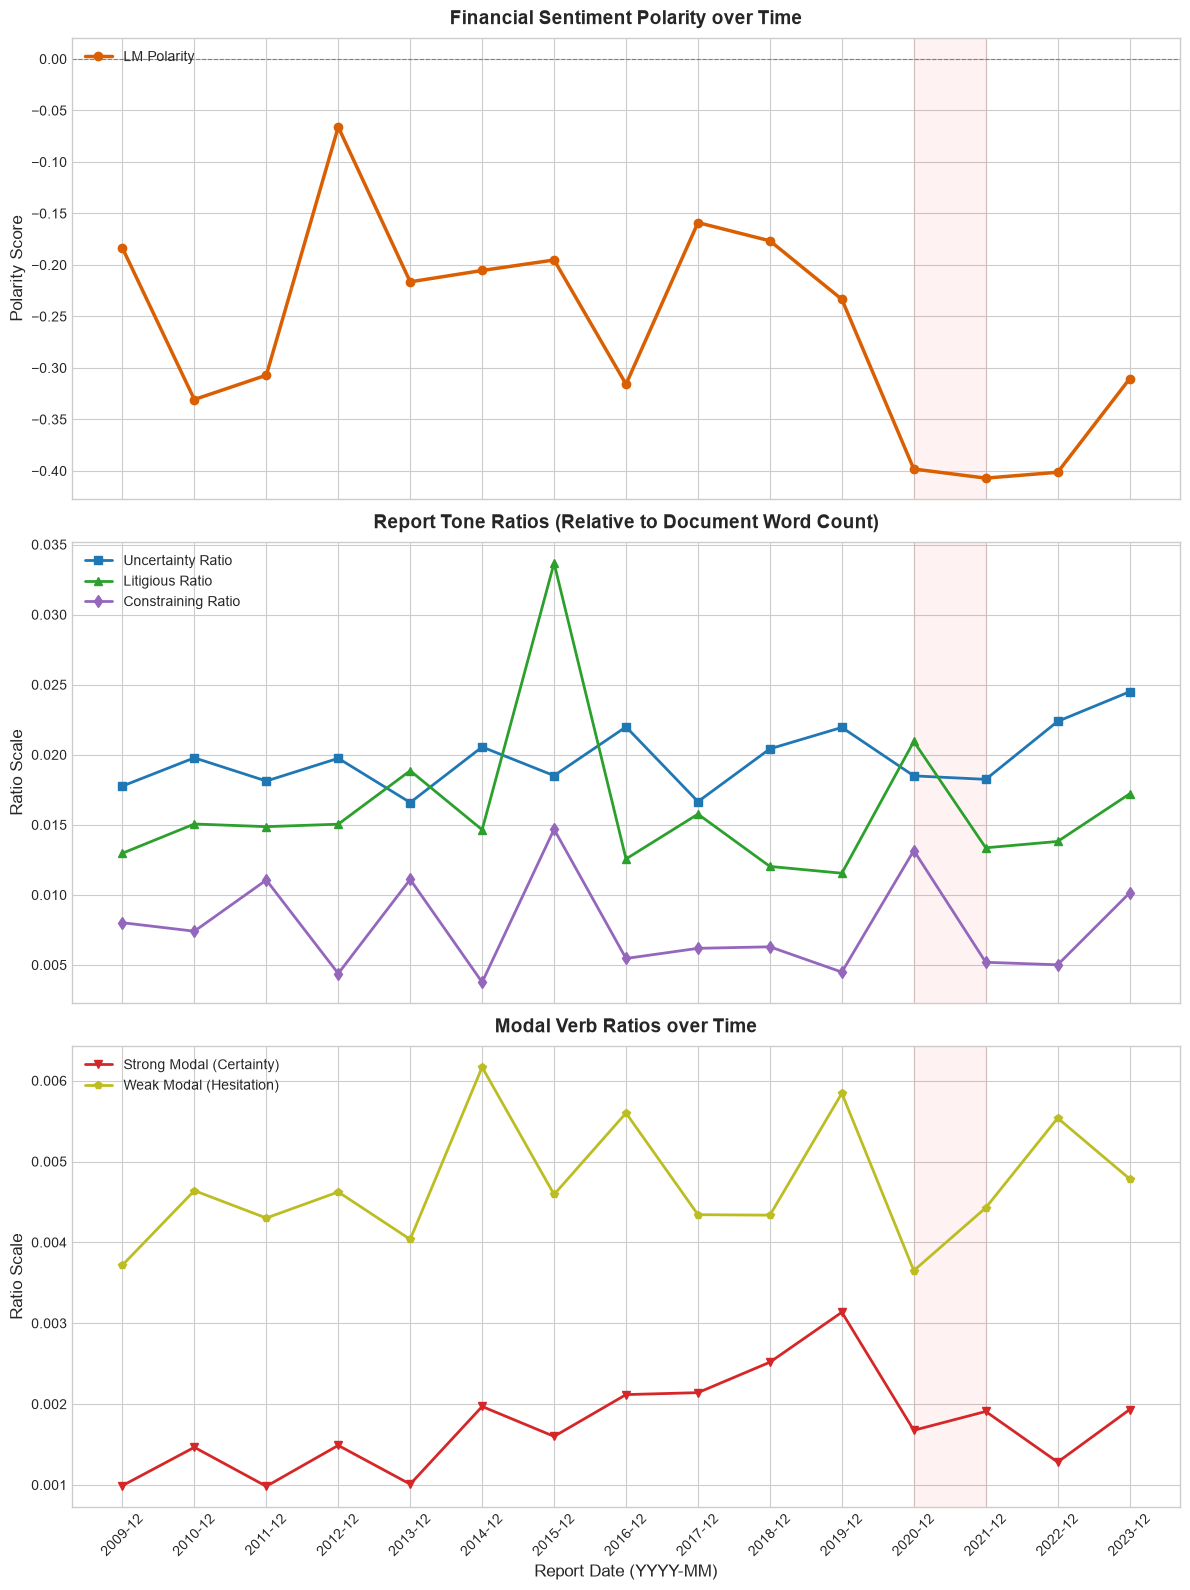

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=True)

# Ensure chronological order for the timeline
df_sorted = df_sentiment.sort_values('report_date')
x_dates = df_sorted['report_date']

# SUBPLOT 1: SENTIMENT POLARITY TREND 
axes[0].plot(x_dates, df_sorted['lm_polarity'], color='#d95f02', marker='o', linewidth=2.5, label='LM Polarity')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8) # Neutral reference line
axes[0].set_title("Financial Sentiment Polarity over Time", fontsize=14, fontweight='bold', pad=10)
axes[0].set_ylabel("Polarity Score", fontsize=12)
axes[0].legend(loc="upper left")

# SUBPLOT 2: TONE RATIOS (Uncertainty, Litigious, Constraining) 
axes[1].plot(x_dates, df_sorted['uncertainty_ratio'], color='#1f77b4', marker='s', linewidth=2, label='Uncertainty Ratio')
axes[1].plot(x_dates, df_sorted['litigious_ratio'], color='#2ca02c', marker='^', linewidth=2, label='Litigious Ratio')
axes[1].plot(x_dates, df_sorted['constraining_ratio'], color='#9467bd', marker='d', linewidth=2, label='Constraining Ratio')
axes[1].set_title("Report Tone Ratios (Relative to Document Word Count)", fontsize=14, fontweight='bold', pad=10)
axes[1].set_ylabel("Ratio Scale", fontsize=12)
axes[1].legend(loc="upper left")

# SUBPLOT 3: MODAL RATIOS (Strong vs. Weak Verbs) 
axes[2].plot(x_dates, df_sorted['strong_modal_ratio'], color='#d62728', marker='v', linewidth=2, label='Strong Modal (Certainty)')
axes[2].plot(x_dates, df_sorted['weak_modal_ratio'], color='#bcbd22', marker='p', linewidth=2, label='Weak Modal (Hesitation)')
axes[2].set_title("Modal Verb Ratios over Time", fontsize=14, fontweight='bold', pad=10)
axes[2].set_ylabel("Ratio Scale", fontsize=12)
axes[2].set_xlabel("Report Date (YYYY-MM)", fontsize=12)
axes[2].legend(loc="upper left")

# 3. Global axis formatting and layout cleanup
for ax in axes:
  ax.tick_params(axis='x', rotation=45)
  ax.tick_params(axis='both', labelsize=10)
  # Optional: Highlight major economic shock periods (e.g., Covid-19 crisis)
  ax.axvspan('2020-12', '2021-12', color='red', alpha=0.05, label='Pandemic Shock Era')

plt.tight_layout()
plt.show()


### Vader Lexicon - Intensifying phrases

In [17]:
# nltk.download('vader_lexicon')

# from nltk.sentiment.vader import SentimentIntensityAnalyzer

# sia = SentimentIntensityAnalyzer()

# # Get the INTENSIFIER/BOOSTER dictionary from VADER
# vader_intensifiers = sia.constants.BOOSTER_DICT

# # Keep ONLY actual intensifiers (where weight > 0)
# vader_intensifiers = {word: weight for word, weight in vader_intensifiers.items() if weight > 0}

# # Print the total counts and a small sample

# print(f"Total Intensifying Words (Stemmed): {len(vader_intensifiers)}")
# print(f"Sample Intensifying Words: {sorted(list(vader_intensifiers))[:15]}\n")

In [18]:
# # Define the scanning and combining function
# def scan_and_combine_boosters(token_list):
#     """
#     Iterates through a list of tokens. If an intensifier is found,
#     it checks the next token. If a next token exists, it combines them
#     using an underscore (e.g., 'extremely' + 'good' -> 'extremely_good').
#     """
#     if not isinstance(token_list, list) or len(token_list) == 0:
#         return []
        
#     combined_tokens = []
#     i = 0
#     n = len(token_list)
    
#     while i < n:
#         current_token = token_list[i].lower()
        
#         # If the current token is an intensifier and not the last element
#         if current_token in vader_intensifiers and i + 1 < n:
#             next_token = token_list[i + 1]
#             # Combine the intensifier with the target word
#             combined_token = f"{current_token}_{next_token}"
#             combined_tokens.append(combined_token)
#             i += 2  # Skip the next token as it has already been merged
#         else:
#             combined_tokens.append(token_list[i])
#             i += 1
            
#     return combined_tokens

# # Get the raw combined list (contains both unigrams and combined bigrams)
# raw_combined = df_sentiment['tokens'].apply(scan_and_combine_boosters)

# # Intensifying phrases: Keep ONLY tokens that contain an underscore '_'
# df_sentiment['combined_tokens'] = raw_combined.apply(
#     lambda token_list: [token for token in token_list if "_" in token]
# )

# # Display a preview of the processed columns
# display(df_sentiment[['tokens', 'combined_tokens', 'cleaned_text', 'word_count']])

$$\begin{gather*} \text{Score} = (1 + w) \times S \\ S = 1 \quad \text{when the target is in } \texttt{positive\_words} \ \\ S = -1 \quad \text{when the target is in } \texttt{negative\_words} \ \\ S = 0 \quad \text{when the target is neutral, or present in both positive and negative word lists.} \\ 1 + w \quad \text{represents the scaling factor (e.g., } \texttt{extremely\_good} \text{ scales to } 1.293 \text{ vs. } \texttt{good} \text{ at } 1.0\text{).} \end{gather*}$$

In [19]:
# B_INCR = sia.constants.B_INCR  # Standard VADER boost constant (0.293)

# # Define the Weighted Sentiment calculation function
# def calculate_weighted_sentiment_polarity(combined_token_list, positive_set, negative_set):
#     """
#     Calculates a weighted sentiment polarity score by multiplying the 
#     booster scale (1 + weight) with the sentiment direction (+1 for positive, -1 for negative).
#     """
#     if not isinstance(combined_token_list, list) or len(combined_token_list) == 0:
#         return 0.0, 0.0, 0.0  # Return (weighted_pos, weighted_neg, weighted_polarity)
        
#     weighted_pos_sum = 0.0
#     weighted_neg_sum = 0.0
    
#     for token in combined_token_list:
#         # Split combined token (e.g., 'extremely_good' -> modifier='extremely', target='good')
#         if "_" not in token:
#             continue
            
#         parts = token.split('_')
#         modifier = parts[0].lower()
#         target = parts[1].lower()
        
#         # Get the booster weight from VADER (fallback to B_INCR if not found)
#         booster_weight = vader_intensifiers.get(modifier, B_INCR)
#         multiplier = 1.0 + booster_weight
        
#         # Determine the sentiment direction using your Loughran-McDonald sets
#         if target in positive_set:
#             weighted_pos_sum += multiplier
#         elif target in negative_set:
#             weighted_neg_sum += multiplier
            
#     # Calculate the Weighted Polarity using the standard formula
#     total_weighted_sentiment = weighted_pos_sum + weighted_neg_sum
    
#     if total_weighted_sentiment > 0:
#         weighted_polarity = (weighted_pos_sum - weighted_neg_sum) / total_weighted_sentiment
#     else:
#         weighted_polarity = 0.0  # Avoid division by zero if no sentiment pairs exist
        
#     return weighted_pos_sum, weighted_neg_sum, weighted_polarity

# # Apply the calculation to your DataFrame
# # Note: positive_words and negative_words are the sets you loaded earlier from pysentiment2
# df_sentiment['weighted_pos'], df_sentiment['weighted_neg'], df_sentiment['weighted_polarity'] = zip(*df_sentiment.apply(
#     lambda row: calculate_weighted_sentiment_polarity(row['combined_tokens'], positive_words, negative_words), 
#     axis=1
# ))

# # Display the newly computed academic metrics
# display(df_sentiment[['combined_tokens', 'weighted_pos', 'weighted_neg', 'weighted_polarity']])
# # Display df with intensification metrics
# display(df_sentiment[['report_date', 
#                         'word_count', 
#                         'lm_positive', 
#                         'lm_negative', 
#                         'lm_polarity', 
#                         'uncertainty_ratio', 
#                         'litigious_ratio', 
#                         'constraining_ratio', 
#                         'strong_modal_ratio', 
#                         'weak_modal_ratio',
#                         'weighted_polarity']])

In [20]:
df

NameError: name 'df' is not defined

# Save to CSV

In [21]:
df_sentiment['report_date'] = (df_sentiment['report_date'] + "-01").str[0:10]

df_sentiment = df_sentiment[['report_date', 'lm_positive', 'lm_negative', 'lm_polarity', 'uncertainty_ratio', 'litigious_ratio', 'constraining_ratio', 'strong_modal_ratio', 'weak_modal_ratio']]

display(df_sentiment)
df_sentiment.to_csv('..\data\model_input\df_processed_text.csv', index=False)

<>:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\nhipk\AppData\Local\Temp\ipykernel_15332\2066936781.py:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df_sentiment.to_csv('..\data\model_input\df_processed_text.csv', index=False)


,report_date,lm_positive,lm_negative,lm_polarity,uncertainty_ratio,litigious_ratio,constraining_ratio,strong_modal_ratio,weak_modal_ratio
0,2009-12-01,278,403,-0.183554,0.017767,0.012974,0.008016,0.000992,0.003719
1,2010-12-01,254,505,-0.330698,0.019782,0.015060,0.007408,0.001465,0.004640
2,2011-12-01,317,598,-0.307104,0.018126,0.014869,0.011060,0.000983,0.004301
3,2012-12-01,396,452,-0.066038,0.019748,0.015046,0.004388,0.001489,0.004623
4,2013-12-01,420,652,-0.216418,0.016592,0.018863,0.011103,0.001009,0.004038
5,2014-12-01,265,402,-0.205397,0.020557,0.014647,0.003769,0.001970,0.006167
6,2015-12-01,301,447,-0.195187,0.018509,0.033679,0.014682,0.001600,0.004593
7,2016-12-01,352,677,-0.315841,0.021990,0.012566,0.005463,0.002117,0.005600
8,2017-12-01,397,547,-0.158898,0.016656,0.015763,0.006186,0.002141,0.004342
9,2018-12-01,359,513,-0.176606,0.020424,0.012030,0.006295,0.002518,0.004337
